In [1]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [2]:
df["TotalCharges"].value_counts().head(20)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
19.45     6
20.3      5
20.45     5
19.85     4
69.9      4
20.4      4
70.6      4
19.2      4
69.65     4
44        4
Name: count, dtype: int64

In [3]:
df["TotalCharges"].tail(20)

7023     6479.4
7024    3626.35
7025     1679.4
7026     403.35
7027     931.55
7028    4326.25
7029     263.05
7030      39.25
7031     3316.1
7032      75.75
7033    2625.25
7034    6886.25
7035     1495.1
7036      743.3
7037     1419.4
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, dtype: object

In [4]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df["customerID"].duplicated().sum()

np.int64(0)

In [6]:
df = df.drop("customerID", axis=1)

In [7]:
df = df.drop("customerID", axis=1)

KeyError: "['customerID'] not found in axis"

In [ ]:
df.columns

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].isnull().sum()

In [ ]:
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df.shape

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X.shape

In [ ]:
y.shape

In [8]:
y.value_counts()

NameError: name 'y' is not defined

In [9]:
y = y.map({"No": 0, "Yes": 1})

NameError: name 'y' is not defined

In [10]:
y.value_counts()

NameError: name 'y' is not defined

In [11]:
X.select_dtypes(include="object").columns

NameError: name 'X' is not defined

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

NameError: name 'X' is not defined

In [ ]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numerical", "passthrough", numerical_cols)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("Before preprocessing:", X_train.shape)
print("After preprocessing:", X_train_processed.shape)

In [ ]:
import xgboost as xgb

print(xgb.__version__)

In [ ]:
%pip install xgboost

In [ ]:
import xgboost as xgb

print(xgb.__version__)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
model.fit(X_train_processed, y_train)

In [13]:
y_pred = model.predict(X_test_processed)

NameError: name 'model' is not defined

In [14]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

NameError: name 'y_test' is not defined

In [15]:
import joblib

joblib.dump(model, "model_v1.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model V1 and preprocessor saved successfully!")

NameError: name 'model' is not defined

In [16]:
import os

print(os.path.exists("model_v1.pkl"))
print(os.path.exists("preprocessor.pkl"))

True
True


In [17]:
import joblib

joblib.dump(model, "model_v1.pkl")
joblib.dump(preprocessor, "preprocessor_v1.pkl")

print("Model V1 saved successfully!")

NameError: name 'model' is not defined

In [18]:
import os

print("Model:", os.path.exists("model_v1.pkl"))
print("Preprocessor:", os.path.exists("preprocessor_v1.pkl"))

Model: True
Preprocessor: True


In [19]:
import json

model_info = {
    "model_version": "v1",
    "algorithm": "XGBoost",
    "training_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "features_before_encoding": int(X_train.shape[1]),
    "features_after_encoding": int(X_train_processed.shape[1]),
    "accuracy": float(accuracy)
}

with open("model_v1_metadata.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Model metadata saved successfully!")
print(model_info)

NameError: name 'X_train' is not defined

In [20]:
import os

files = [
    "model_v1.pkl",
    "preprocessor_v1.pkl",
    "model_v1_metadata.json"
]

for file in files:
    print(file, "→", os.path.exists(file))

model_v1.pkl → True
preprocessor_v1.pkl → True
model_v1_metadata.json → True


In [21]:
%pip install mlflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
import mlflow

print(mlflow.__version__)

3.15.2


In [24]:
import mlflow

mlflow.set_experiment("Telco_Customer_Churn")

print("MLflow experiment is ready!")

PermissionError: [WinError 5] Access is denied: 'C:\\Users\\Suresh%20Krishna%20K'

In [25]:
import os

mlflow_dir = os.path.abspath("mlruns")

os.makedirs(mlflow_dir, exist_ok=True)

print(mlflow_dir)

C:\Users\Suresh Krishna K\mlruns


In [26]:
import mlflow

mlflow.set_tracking_uri("file:///" + mlflow_dir.replace("\\", "/"))

print("MLflow tracking location:")
print(mlflow.get_tracking_uri())

MLflow tracking location:
file:///C:/Users/Suresh Krishna K/mlruns


In [27]:
mlflow.set_experiment("Telco_Customer_Churn")

print("MLflow experiment is ready!")

MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.

In [28]:
import mlflow
import os

db_path = os.path.abspath("mlflow.db")

mlflow.set_tracking_uri("sqlite:///" + db_path)

print("Tracking URI:")
print(mlflow.get_tracking_uri())

Tracking URI:
sqlite:///C:\Users\Suresh Krishna K\mlflow.db


In [29]:
mlflow.set_experiment("Telco_Customer_Churn")

print("MLflow experiment is ready!")

2026/08/30 19:41:23 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/30 19:41:23 INFO mlflow.store.db.utils: Updating database tables
2026/08/30 19:41:27 INFO mlflow.tracking.fluent: Experiment with name 'Telco_Customer_Churn' does not exist. Creating a new experiment.


MLflow experiment is ready!


In [30]:
experiment = mlflow.get_experiment_by_name("Telco_Customer_Churn")

print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)

Experiment name: Telco_Customer_Churn
Experiment ID: 1


In [31]:
import mlflow
import mlflow.xgboost

with mlflow.start_run(run_name="XGBoost_Model_V1"):

    # Model information
    mlflow.log_param("model_version", "v1")
    mlflow.log_param("algorithm", "XGBoost")

    # XGBoost parameters
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)

    # Dataset information
    mlflow.log_param("training_samples", X_train.shape[0])
    mlflow.log_param("test_samples", X_test.shape[0])
    mlflow.log_param("features_after_encoding", X_train_processed.shape[1])

    # Model performance
    mlflow.log_metric("accuracy", accuracy)

    # Save XGBoost model to MLflow
    mlflow.xgboost.log_model(
        model,
        name="xgboost_model"
    )

    print("Model V1 logged successfully!")

NameError: name 'X_train' is not defined

In [32]:
import os

print("Current files:")
print(os.listdir())
import joblib

model = joblib.load("model_v1.pkl")
preprocessor = joblib.load("preprocessor_v1.pkl")

print("Model and preprocessor loaded successfully!")
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna(subset=["TotalCharges"])

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

print(X.shape)
print(y.shape)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Current files:
['.anaconda', '.antigravity', '.blackbox-editor', '.cache', '.conda', '.continuum', '.copilot', '.deepface', '.ganttproject', '.ganttproject.d', '.gemini', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.matplotlib', '.ms-ad', '.ollama', '.packettracer', '.streamlit', '.vscode', '.vscode-shared', '.wdm', '3W34.html', 'ann.pkl', 'AppData', 'Application Data', 'Cisco Packet Tracer 7.3.0', 'columns.pkl', 'Contacts', 'Cookies', 'customer_data.xlsx', 'deep_learning.ipynb', 'deep_learningipynb', 'Deep_learning_2.0.ipynb', 'Documents', 'Downloads', 'Favorites', 'flask', 'ganttproject.log', 'gb.pkl', 'Hello-World', 'housing_prices.csv', 'housing_prices.xlsx', 'housing_prices123.csv', 'java0.log', 'Links', 'Local Settings', 'ML 1.0.ipynb', 'ml project .ipynb', 'ml.ipynb', 'mlflow.db', 'mlruns', 'model_v1.pkl', 'model_v1_metadata.json', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT

In [37]:
import mlflow
import mlflow.xgboost

# Make sure MLflow uses your SQLite database
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Select your experiment
mlflow.set_experiment("Telco_Customer_Churn")

with mlflow.start_run(run_name="XGBoost_Model_V1"):

    # Model information
    mlflow.log_param("model_version", "v1")
    mlflow.log_param("algorithm", "XGBoost")

    # Model parameters
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)

    # Dataset information
    mlflow.log_param("training_samples", X_train.shape[0])
    mlflow.log_param("test_samples", X_test.shape[0])
    mlflow.log_param(
        "features_after_encoding",
        X_train_processed.shape[1]
    )

    # Performance
    mlflow.log_metric("accuracy", accuracy)

    # Save model to MLflow
    mlflow.xgboost.log_model(
        model,
        name="xgboost_model"
    )

    print("✅ Model V1 logged successfully!")

✅ Model V1 logged successfully!


In [39]:
runs = mlflow.search_runs()

print("Number of runs:", len(runs))
print("\nAvailable columns:")
print(runs.columns.tolist())

Number of runs: 6

Available columns:
['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time', 'metrics.accuracy', 'params.algorithm', 'params.max_depth', 'params.n_estimators', 'params.features_after_encoding', 'params.learning_rate', 'params.test_samples', 'params.training_samples', 'params.model_version', 'tags.mlflow.user', 'tags.mlflow.runName', 'tags.mlflow.source.name', 'tags.mlflow.source.type']


In [40]:
print(runs)

                             run_id experiment_id    status  \
0  8316a1be3cbb4f5895643ffcf5b494ba             1  FINISHED   
1  41e59fe5dcbd48308b163ec350db60f3             1  FINISHED   
2  de448d30f54240eb8e8ad3b7930b570c             1  FINISHED   
3  e7b567898f2a4405b9350158399b0c0b             1  FINISHED   
4  f9d8cd40981b472f82c02ff05126da2e             1  FINISHED   
5  bbfa531214f6405ba4d5720b4372d020             1    FAILED   

                                        artifact_uri  \
0  file:C:/Users/Suresh Krishna K/mlruns/1/8316a1...   
1  file:C:/Users/Suresh Krishna K/mlruns/1/41e59f...   
2  file:C:/Users/Suresh Krishna K/mlruns/1/de448d...   
3  file:C:/Users/Suresh Krishna K/mlruns/1/e7b567...   
4  file:C:/Users/Suresh Krishna K/mlruns/1/f9d8cd...   
5  file:C:/Users/Suresh Krishna K/mlruns/1/bbfa53...   

                        start_time                         end_time  \
0 2026-08-30 14:16:01.253000+00:00 2026-08-30 14:16:08.883000+00:00   
1 2026-08-30 14:15:47.7

In [41]:
import os

print("Model exists:", os.path.exists("model_v1.pkl"))
print("Preprocessor exists:", os.path.exists("preprocessor_v1.pkl"))
print("Metadata exists:", os.path.exists("model_v1_metadata.json"))


Model exists: True
Preprocessor exists: True
Metadata exists: True


In [42]:
import os
os.getcwd()

'C:\\Users\\Suresh Krishna K'

In [43]:
import os

print(os.listdir())

['.anaconda', '.antigravity', '.blackbox-editor', '.cache', '.conda', '.continuum', '.copilot', '.deepface', '.ganttproject', '.ganttproject.d', '.gemini', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.matplotlib', '.ms-ad', '.ollama', '.packettracer', '.streamlit', '.vscode', '.vscode-shared', '.wdm', '3W34.html', 'ann.pkl', 'AppData', 'Application Data', 'Cisco Packet Tracer 7.3.0', 'columns.pkl', 'Contacts', 'Cookies', 'customer_data.xlsx', 'deep_learning.ipynb', 'deep_learningipynb', 'Deep_learning_2.0.ipynb', 'Documents', 'Downloads', 'Favorites', 'flask', 'ganttproject.log', 'gb.pkl', 'Hello-World', 'housing_prices.csv', 'housing_prices.xlsx', 'housing_prices123.csv', 'java0.log', 'Links', 'Local Settings', 'ML 1.0.ipynb', 'ml project .ipynb', 'ml.ipynb', 'mlflow.db', 'mlruns', 'model_v1.pkl', 'model_v1_metadata.json', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-

In [44]:
import os

print(os.path.exists("model_v1.pkl"))
print(os.path.exists("preprocessor_v1.pkl"))

True
True


In [45]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_processed, y_train)

log_pred = log_model.predict(X_test_processed)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [47]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_processed, y_train)

dt_pred = dt_model.predict(X_test_processed)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Predictions
predictions = {
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred,
    "Decision Tree": dt_pred,
    "XGBoost": y_pred
}

results = []

for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.789623,0.602094,0.614973,0.608466
1,Logistic Regression,0.803127,0.645646,0.574866,0.608204
2,XGBoost,0.790334,0.625397,0.526738,0.571843
3,Random Forest,0.786780,0.624161,0.497326,0.553571


In [49]:
best_model_name = comparison_df.loc[0, "Model"]

print("Best Model:", best_model_name)
print("F1-Score:", comparison_df.loc[0, "F1-Score"])
print("Accuracy:", comparison_df.loc[0, "Accuracy"])

Best Model: Decision Tree
F1-Score: 0.6084656084656085
Accuracy: 0.7896233120113717


In [50]:
model_map = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Decision Tree": dt_model,
    "XGBoost": model
}

best_model = model_map[best_model_name]

print("✅ Selected:", best_model_name)

✅ Selected: Decision Tree


In [51]:
import joblib

joblib.dump(best_model, "model_best.pkl")

print("✅ Best model saved as model_best.pkl")

✅ Best model saved as model_best.pkl


In [55]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Telco_Customer_Churn")

with mlflow.start_run(run_name="Model_Comparison_V1"):

    # Log which model was selected
    mlflow.log_param("selection_metric", "F1-Score")
    mlflow.log_param("best_model", best_model_name)

    # Log performance of all models
    for _, row in comparison_df.iterrows():
        model_name = row["Model"]

        mlflow.log_metric(
            f"{model_name}_accuracy",
            row["Accuracy"]
        )

        mlflow.log_metric(
            f"{model_name}_precision",
            row["Precision"]
        )

        mlflow.log_metric(
            f"{model_name}_recall",
            row["Recall"]
        )

        mlflow.log_metric(
            f"{model_name}_f1",
            row["F1-Score"]
        )

    # Log the selected model's main metrics
    best_row = comparison_df.iloc[0]

    mlflow.log_metric("best_accuracy", best_row["Accuracy"])
    mlflow.log_metric("best_precision", best_row["Precision"])
    mlflow.log_metric("best_recall", best_row["Recall"])
    mlflow.log_metric("best_f1_score", best_row["F1-Score"])

    # Save selected model to MLflow
    mlflow.sklearn.log_model(
        best_model,
        "best_model"
    )

print("✅ Model comparison logged to MLflow!")

2026/08/30 20:13:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Model comparison logged to MLflow!


In [56]:
import pandas as pd
import numpy as np

# Make a copy of the cleaned dataset
data = df.copy()

# Create reference data
reference_data = data.sample(
    n=3000,
    random_state=42
).copy()

# Create simulated production data
production_data = data.drop(
    reference_data.index
).sample(
    n=3000,
    random_state=100
).copy()

print("Reference data:", reference_data.shape)
print("Production data:", production_data.shape)

Reference data: (3000, 20)
Production data: (3000, 20)


In [57]:
print("REFERENCE DATA")
print(reference_data["SeniorCitizen"].value_counts(normalize=True))

print("\nPRODUCTION DATA")
print(production_data["SeniorCitizen"].value_counts(normalize=True))

REFERENCE DATA
SeniorCitizen
0    0.843333
1    0.156667
Name: proportion, dtype: float64

PRODUCTION DATA
SeniorCitizen
0    0.832
1    0.168
Name: proportion, dtype: float64


In [58]:
from scipy.stats import ks_2samp

numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numerical_columns:

    statistic, p_value = ks_2samp(
        reference_data[column],
        production_data[column]
    )

    print(f"\nFeature: {column}")
    print(f"KS Statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("⚠️ Drift detected")
    else:
        print("✅ No significant drift")


Feature: tenure
KS Statistic: 0.0250
P-value: 0.3056
✅ No significant drift

Feature: MonthlyCharges
KS Statistic: 0.0150
P-value: 0.8885
✅ No significant drift

Feature: TotalCharges
KS Statistic: 0.0183
P-value: 0.6945
✅ No significant drift


In [59]:
# Create a copy of production data
drifted_data = production_data.copy()

# Simulate a change in customer behavior
drifted_data["MonthlyCharges"] = drifted_data["MonthlyCharges"] * 1.30

print("Original average MonthlyCharges:")
print(production_data["MonthlyCharges"].mean())

print("\nDrifted average MonthlyCharges:")
print(drifted_data["MonthlyCharges"].mean())

Original average MonthlyCharges:
64.7611

Drifted average MonthlyCharges:
84.18943


In [60]:
statistic, p_value = ks_2samp(
    reference_data["MonthlyCharges"],
    drifted_data["MonthlyCharges"]
)

print("KS Statistic:", round(statistic, 4))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("⚠️ DRIFT DETECTED")
else:
    print("✅ NO SIGNIFICANT DRIFT")

KS Statistic: 0.311
P-value: 0.0
⚠️ DRIFT DETECTED


In [61]:
from scipy.stats import ks_2samp

def detect_numerical_drift(reference_data, current_data, columns, threshold=0.05):
    
    results = []

    for column in columns:
        
        statistic, p_value = ks_2samp(
            reference_data[column],
            current_data[column]
        )
        
        drift = p_value < threshold
        
        results.append({
            "Feature": column,
            "KS_Statistic": statistic,
            "P_Value": p_value,
            "Drift": drift
        })

    return pd.DataFrame(results)

In [62]:
drift_results = detect_numerical_drift(
    reference_data,
    production_data,
    numerical_columns
)

drift_results

,Feature,KS_Statistic,P_Value,Drift
0,tenure,0.025000,0.305642,False
1,MonthlyCharges,0.015000,0.888539,False
2,TotalCharges,0.018333,0.694540,False


In [63]:
drift_results = detect_numerical_drift(
    reference_data,
    drifted_data,
    numerical_columns
)

drift_results

,Feature,KS_Statistic,P_Value,Drift
0,tenure,0.025000,3.056419e-01,False
1,MonthlyCharges,0.311000,1.558111e-128,True
2,TotalCharges,0.018333,6.945404e-01,False


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Probability predictions
y_prob = model.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("MODEL PERFORMANCE ANALYSIS")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

MODEL PERFORMANCE ANALYSIS
--------------------------
Accuracy : 0.7903340440653873
Precision: 0.6253968253968254
Recall   : 0.5267379679144385
F1-Score : 0.5718432510885341
ROC-AUC  : 0.8371119370920067


Confusion Matrix:
[[915 118]
 [177 197]]


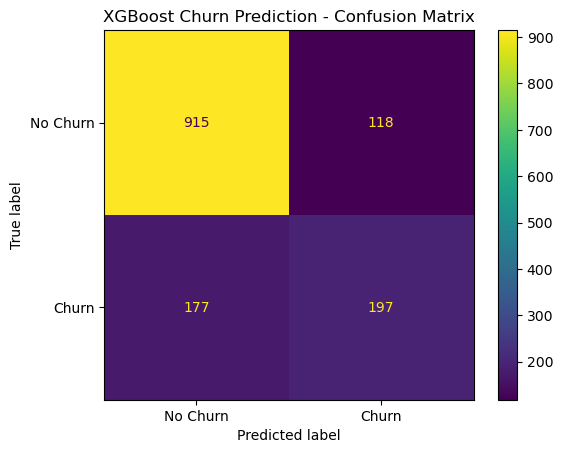

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("XGBoost Churn Prediction - Confusion Matrix")
plt.show()

In [66]:
print("Classification Report")
print("---------------------")

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report
---------------------
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [67]:
# Causal analysis - churn rate by important customer factors

causal_columns = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling",
    "Partner",
    "Dependents"
]

for column in causal_columns:
    print("\n====================================")
    print("Factor:", column)
    print("====================================")

    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(churn_rate)


Factor: Contract
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

Factor: InternetService
InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64

Factor: OnlineSecurity
OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: Churn, dtype: float64

Factor: TechSupport
TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: Churn, dtype: float64

Factor: PaymentMethod
PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

Factor: PaperlessBilling
PaperlessBilling
Yes    33.589251
No     16.375698
Name: Churn, dtype: float64

Factor: Partner
Partner
No     32.976092
Yes    19.717065
Name: 

In [68]:
# Calculate churn rate differences

causal_results = []

for column in causal_columns:

    rates = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

    difference = rates.max() - rates.min()

    causal_results.append({
        "Factor": column,
        "Highest_Churn_Rate": rates.max(),
        "Lowest_Churn_Rate": rates.min(),
        "Difference": difference
    })

causal_df = pd.DataFrame(causal_results)

causal_df = causal_df.sort_values(
    "Difference",
    ascending=False
)

causal_df

,Factor,Highest_Churn_Rate,Lowest_Churn_Rate,Difference
0,Contract,42.709677,2.848665,39.861013
1,InternetService,41.892765,7.434211,34.458554
2,OnlineSecurity,41.778667,7.434211,34.344457
3,TechSupport,41.647465,7.434211,34.213255
4,PaymentMethod,45.285412,15.253123,30.032289
5,PaperlessBilling,33.589251,16.375698,17.213553
7,Dependents,31.279140,15.531205,15.747935
6,Partner,32.976092,19.717065,13.259028


In [69]:
# DIGITAL TWIN - Create a simulated customer

digital_twin = df.drop(columns=["Churn"]).iloc[[0]].copy()

print("Original Customer:")
display(digital_twin)

Original Customer:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85


In [70]:
# Predict original customer's churn probability

digital_twin_processed = preprocessor.transform(digital_twin)

original_probability = model.predict_proba(
    digital_twin_processed
)[:, 1][0]

print("Original Churn Probability:",
      round(original_probability * 100, 2), "%")

Original Churn Probability: 65.53 %


In [71]:
# Create a simulated version of the customer

digital_twin_changed = digital_twin.copy()

digital_twin_changed["Contract"] = "Two year"

# Process simulated customer
changed_processed = preprocessor.transform(
    digital_twin_changed
)

changed_probability = model.predict_proba(
    changed_processed
)[:, 1][0]

print("Original Churn Probability:",
      round(original_probability * 100, 2), "%")

print("After Contract Change:",
      round(changed_probability * 100, 2), "%")

print("Change:",
      round((changed_probability - original_probability) * 100, 2),
      "percentage points")

Original Churn Probability: 65.53 %
After Contract Change: 21.77 %
Change: -43.77 percentage points


In [72]:
# Digital Twin - Multiple What-If Scenarios

contracts = [
    "Month-to-month",
    "One year",
    "Two year"
]

for contract in contracts:

    simulated_customer = digital_twin.copy()
    simulated_customer["Contract"] = contract

    processed = preprocessor.transform(
        simulated_customer
    )

    probability = model.predict_proba(
        processed
    )[:, 1][0]

    print(
        contract,
        "->",
        round(probability * 100, 2),
        "% churn probability"
    )

Month-to-month -> 65.53 % churn probability
One year -> 23.95 % churn probability
Two year -> 21.77 % churn probability


In [73]:
# DECISION ENGINE

DRIFT_THRESHOLD = 0.05
F1_THRESHOLD = 0.60

print("Decision Engine configured")
print("Drift threshold:", DRIFT_THRESHOLD)
print("F1-score threshold:", F1_THRESHOLD)

Decision Engine configured
Drift threshold: 0.05
F1-score threshold: 0.6


In [74]:
# Check whether any feature has drifted

drift_detected = drift_results["Drift"].any()

print("Drift detected:", drift_detected)

Drift detected: True


In [75]:
current_f1 = f1

print("Current Model F1-Score:", round(current_f1, 4))

Current Model F1-Score: 0.5718


In [76]:
# Decision Engine

if drift_detected and current_f1 < F1_THRESHOLD:
    decision = "RETRAIN"
    reason = "Drift detected and model performance is below threshold."

elif drift_detected:
    decision = "MONITOR"
    reason = "Drift detected, but model performance is still acceptable."

elif current_f1 < F1_THRESHOLD:
    decision = "RETRAIN"
    reason = "Model performance is below threshold."

else:
    decision = "CONTINUE"
    reason = "No significant drift and model performance is acceptable."

print("Decision:", decision)
print("Reason:", reason)

Decision: RETRAIN
Reason: Drift detected and model performance is below threshold.


In [77]:
# ARCS - Drift Score

drift_score = drift_results["KS_Statistic"].mean()

print("Drift Score:", round(drift_score, 4))

Drift Score: 0.1181


In [78]:
# ARCS - Performance Risk

target_f1 = 0.60

performance_risk = max(
    0,
    (target_f1 - current_f1) / target_f1
)

print("Current F1:", round(current_f1, 4))
print("Performance Risk:", round(performance_risk, 4))

Current F1: 0.5718
Performance Risk: 0.0469


In [79]:
# ARCS Calculation

arcs = (
    0.5 * drift_score +
    0.5 * performance_risk
)

arcs = min(max(arcs, 0), 1)

print("Drift Score:", round(drift_score, 4))
print("Performance Risk:", round(performance_risk, 4))
print("ARCS:", round(arcs, 4))
print("ARCS (%):", round(arcs * 100, 2), "%")

Drift Score: 0.1181
Performance Risk: 0.0469
ARCS: 0.0825
ARCS (%): 8.25 %


In [80]:
# ARCS Decision

if arcs >= 0.70:
    arcs_decision = "HIGH - Retraining Recommended"
elif arcs >= 0.40:
    arcs_decision = "MEDIUM - Monitor and Simulate"
else:
    arcs_decision = "LOW - Continue Current Model"

print("ARCS Decision:", arcs_decision)

ARCS Decision: LOW - Continue Current Model


In [81]:
# STEP 11 - AUTO RETRAINING ENGINE

def auto_retrain(arcs_score, threshold=0.70):
    
    if arcs_score < threshold:
        print("ARCS is below retraining threshold.")
        print("No retraining required.")
        return False
    
    print("⚠️ ARCS is high.")
    print("Retraining required.")
    
    return True


retraining_required = auto_retrain(arcs)

print("\nRetraining Required:", retraining_required)

ARCS is below retraining threshold.
No retraining required.

Retraining Required: False


In [85]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score


def retrain_model(X_train_processed, y_train, X_test_processed, y_test):

    print("Starting model retraining...")

    new_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )

    # Train the new model
    new_model.fit(
        X_train_processed,
        y_train
    )

    # Predictions
    new_predictions = new_model.predict(
        X_test_processed
    )

    # Performance
    new_accuracy = accuracy_score(
        y_test,
        new_predictions
    )

    new_f1 = f1_score(
        y_test,
        new_predictions
    )

    print("Retraining completed.")
    print("New Accuracy:", round(new_accuracy, 4))
    print("New F1-Score:", round(new_f1, 4))

    return new_model, new_accuracy, new_f1

In [86]:
new_model, new_accuracy, new_f1 = retrain_model(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

Starting model retraining...
Retraining completed.
New Accuracy: 0.7903
New F1-Score: 0.5718


In [87]:
print("========== MODEL COMPARISON ==========")

print("Old Model Accuracy:", round(accuracy, 4))
print("New Model Accuracy:", round(new_accuracy, 4))

print("Old Model F1:", round(f1, 4))
print("New Model F1:", round(new_f1, 4))

========== MODEL COMPARISON ==========
Old Model Accuracy: 0.7903
New Model Accuracy: 0.7903
Old Model F1: 0.5718
New Model F1: 0.5718


In [88]:
# STEP 12 - MODEL VALIDATION

print("========== MODEL VALIDATION ==========")

accuracy_improved = new_accuracy > accuracy
f1_improved = new_f1 > f1

print("Old Accuracy:", round(accuracy, 4))
print("New Accuracy:", round(new_accuracy, 4))

print("Old F1-Score:", round(f1, 4))
print("New F1-Score:", round(new_f1, 4))

if accuracy_improved or f1_improved:
    print("\n✅ New model performs better.")
    print("Validation Result: ACCEPT NEW MODEL")
else:
    print("\n⚠️ New model does not improve performance.")
    print("Validation Result: KEEP OLD MODEL")

========== MODEL VALIDATION ==========
Old Accuracy: 0.7903
New Accuracy: 0.7903
Old F1-Score: 0.5718
New F1-Score: 0.5718

⚠️ New model does not improve performance.
Validation Result: KEEP OLD MODEL


In [89]:
# ==========================================
# STEP 12 - MODEL VALIDATION
# ==========================================

print("========== MODEL VALIDATION ==========")

# Check accuracy
accuracy_difference = new_accuracy - accuracy

# Check F1 score
f1_difference = new_f1 - f1

print("Old Accuracy :", round(accuracy, 4))
print("New Accuracy :", round(new_accuracy, 4))
print("Accuracy Difference :", round(accuracy_difference, 4))

print("\nOld F1-Score :", round(f1, 4))
print("New F1-Score :", round(new_f1, 4))
print("F1 Difference :", round(f1_difference, 4))

# Validation decision
if new_accuracy >= accuracy and new_f1 >= f1:
    validation_status = "PASS"
    print("\n✅ Validation PASSED")
    print("New model is equal or better than the old model.")
else:
    validation_status = "FAIL"
    print("\n⚠️ Validation FAILED")
    print("New model performance is lower than the old model.")

print("\nValidation Status:", validation_status)

========== MODEL VALIDATION ==========
Old Accuracy : 0.7903
New Accuracy : 0.7903
Accuracy Difference : 0.0

Old F1-Score : 0.5718
New F1-Score : 0.5718
F1 Difference : 0.0

✅ Validation PASSED
New model is equal or better than the old model.

Validation Status: PASS


In [90]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ---------------

In [91]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [92]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP analysis completed!")
print("SHAP shape:", shap_values.shape)

SHAP analysis completed!
SHAP shape: (1407, 45)


In [93]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("Number of SHAP features:", shap_values.shape[1])

Number of features: 45
Number of SHAP features: 45


In [94]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Importance",
    ascending=False
)

print("========== TOP 10 CHURN FEATURES ==========")
print(shap_importance.head(10))

========== TOP 10 CHURN FEATURES ==========
                                        Feature  Importance
32         categorical__Contract_Month-to-month    0.774364
42                            numerical__tenure    0.439182
43                    numerical__MonthlyCharges    0.287337
14               categorical__OnlineSecurity_No    0.244874
44                      numerical__TotalCharges    0.182740
23                  categorical__TechSupport_No    0.174828
39  categorical__PaymentMethod_Electronic check    0.141591
8                 categorical__MultipleLines_No    0.138723
12     categorical__InternetService_Fiber optic    0.133488
34               categorical__Contract_Two year    0.112838


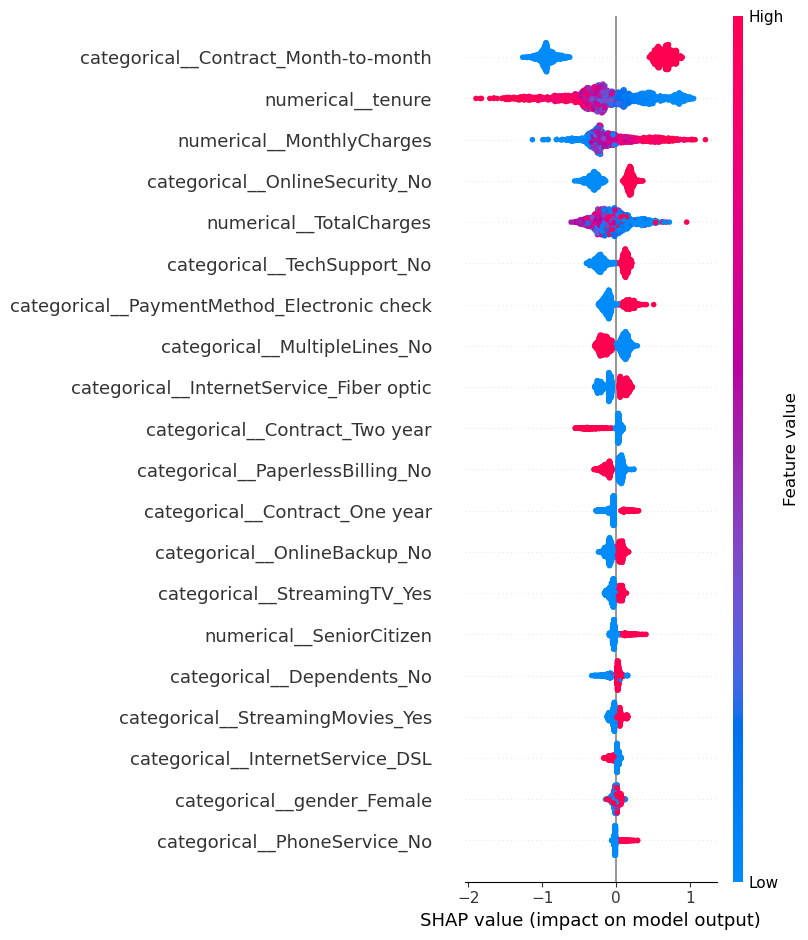

In [95]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [96]:
# ==========================================
# STEP 14 - OUTCOME ANALYSIS
# ==========================================

print("========================================")
print("       FINAL OUTCOME ANALYSIS")
print("========================================")

print("\n1. MODEL PERFORMANCE")
print("--------------------")
print("Model: XGBoost")
print("Accuracy:", round(accuracy, 4))
print("F1-Score:", round(f1, 4))

print("\n2. DRIFT ANALYSIS")
print("-----------------")
print("Drift Score:", round(drift_score, 4))

print("\n3. PERFORMANCE RISK")
print("-------------------")
print("Performance Risk:", round(performance_risk, 4))

print("\n4. ARCS DECISION")
print("----------------")
print("ARCS Score:", round(arcs, 4))
print("ARCS (%):", round(arcs * 100, 2), "%")

if arcs < 0.70:
    print("Decision: LOW - Continue Current Model")
else:
    print("Decision: HIGH - Retraining Required")

print("\n5. RETRAINING")
print("-------------")
print("Old Accuracy:", round(accuracy, 4))
print("New Accuracy:", round(new_accuracy, 4))
print("Old F1:", round(f1, 4))
print("New F1:", round(new_f1, 4))

print("\n6. VALIDATION")
print("-------------")
print("Validation Status:", validation_status)

print("\n7. TOP CHURN FEATURES")
print("---------------------")

top_features = shap_importance.head(10)

for i, row in enumerate(top_features.itertuples(), 1):
    print(
        i,
        "-",
        row.Feature,
        ":",
        round(row.Importance, 4)
    )

print("\n========================================")
print("       PROJECT PIPELINE COMPLETED")
print("========================================")

       FINAL OUTCOME ANALYSIS

1. MODEL PERFORMANCE
--------------------
Model: XGBoost
Accuracy: 0.7903
F1-Score: 0.5718

2. DRIFT ANALYSIS
-----------------
Drift Score: 0.1181

3. PERFORMANCE RISK
-------------------
Performance Risk: 0.0469

4. ARCS DECISION
----------------
ARCS Score: 0.0825
ARCS (%): 8.25 %
Decision: LOW - Continue Current Model

5. RETRAINING
-------------
Old Accuracy: 0.7903
New Accuracy: 0.7903
Old F1: 0.5718
New F1: 0.5718

6. VALIDATION
-------------
Validation Status: PASS

7. TOP CHURN FEATURES
---------------------
1 - categorical__Contract_Month-to-month : 0.7744
2 - numerical__tenure : 0.4392
3 - numerical__MonthlyCharges : 0.2873
4 - categorical__OnlineSecurity_No : 0.2449
5 - numerical__TotalCharges : 0.1827
6 - categorical__TechSupport_No : 0.1748
7 - categorical__PaymentMethod_Electronic check : 0.1416
8 - categorical__MultipleLines_No : 0.1387
9 - categorical__InternetService_Fiber optic : 0.1335
10 - categorical__Contract_Two year : 0.1128

    

In [97]:
cd

C:\Users\Suresh Krishna K
